# **Lab 4.1 Data Augmentation with PyTorch**

In [8]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os
from collections import Counter
from mpl_toolkits.axes_grid1 import ImageGrid
import zipfile
from PIL import Image

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return DataLoader() and print the information about the Dataset.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>), [`ImageFolder`](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html), [`Dataloader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#:~:text=Preparing%20your%20data%20for%20training%20with%20DataLoaders)

In [9]:
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((400, 400)),
        transforms.Pad(20),
        transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=20),
        transforms.CenterCrop(200),
        transforms.ToTensor()
    ])

    dataset = ImageFolder(root=path, transform=transform)

    class_map = dataset.class_to_idx #{'battleship': 0, 'patrol boat': 1, 'submarine': 2}
    targets = dataset.targets  #[0, 0, 1, 2, 1, ...]
    class_counts = Counter(targets)
    idx_to_class = {v: k for k, v in class_map.items()}

    data_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=16, pin_memory=True)

    print("Train Dataset")
    for label in sorted(idx_to_class.keys()):
        class_name = idx_to_class[label]
        count = class_counts[label]
        print(f"\tNumber of images in class {class_name}: {count}")
    print(f"\tNumber of samples: {len(dataset)}")

    images, labels = next(iter(data_loader))

    fig = plt.figure(figsize=(20, 20))
    plt.style.use('dark_background')

    grid = ImageGrid(fig, 111,
                    nrows_ncols=(4, 4),  
                    axes_pad=0.5,  
                    )

    for ax, im, lb in zip(grid, images, labels):
        im_np = im.permute(1, 2, 0).numpy()
        ax.axis('off')
        ax.set_title(lb.item())
        ax.imshow(im_np)

    plt.show()

    return data_loader

    ### END CODE HERE ###

Use your load_data() function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/01.png?raw=true)

</details>

📂 Already extracted at: Ship
Train Dataset
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114


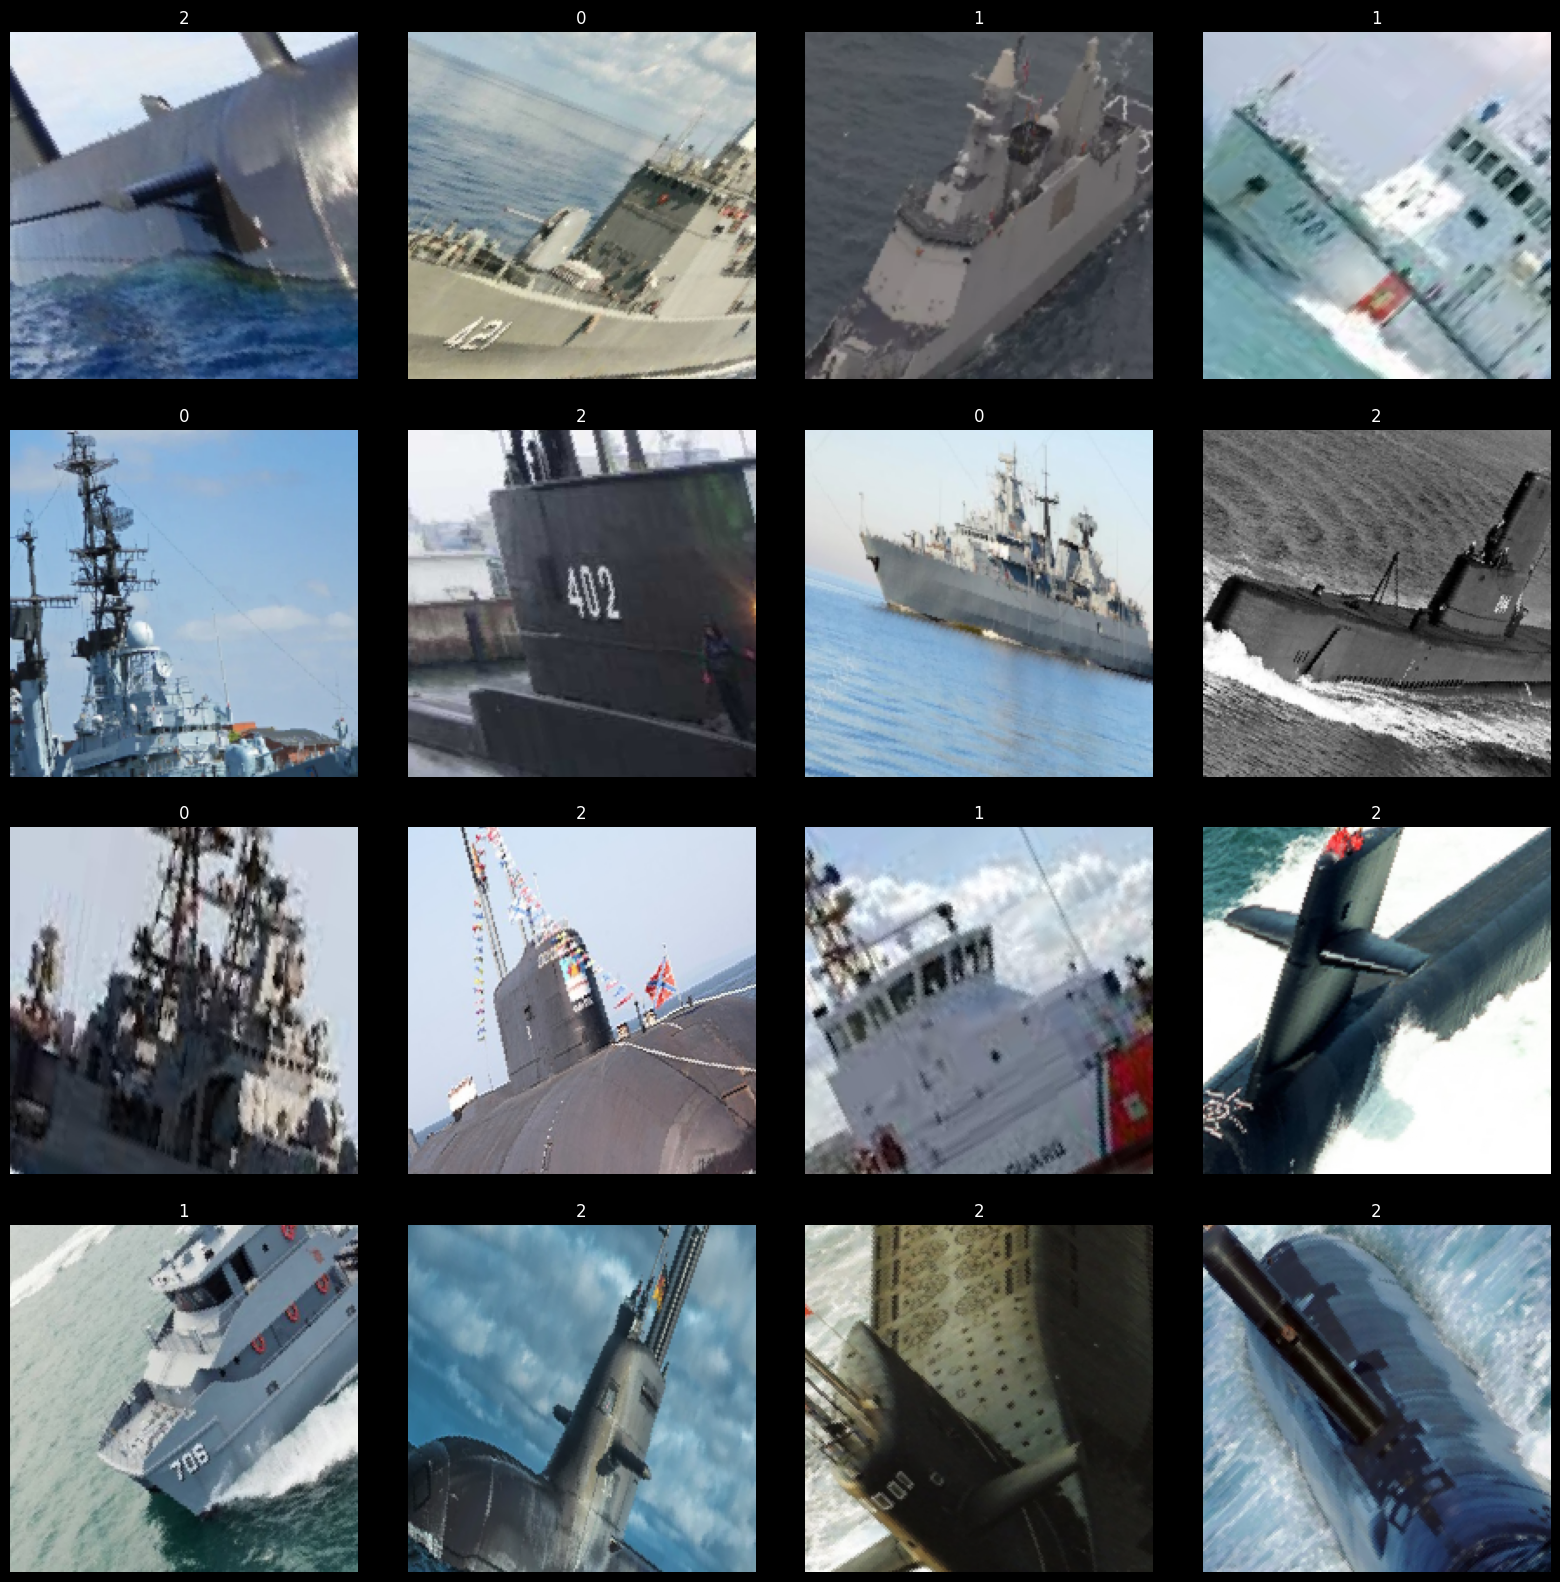

In [10]:
### START CODE HERE ###
def unzip_data(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
            print(f"✅ Unzipped to: {extract_to}")
    else:
        print(f"📂 Already extracted at: {extract_to}")

unzip_data("Ship.zip", "Ship")

data_loader = load_data('./Ship/Ship/Train')

### END CODE HERE ###

Now, let's create your own `CustomImageDataset` that performs the augmentation as in the previous section, but also includes the methods `add_gaussian_blur()` and `add_gaussian_noise()`. **<font color="red">DO NOT</font>** use `transforms.Compose()`.

Resource : [CustomImageDataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#:~:text=.show()-,Dataset%20class,-torch.utils.data)

In [15]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_dir, output_size=224, apply_blur=False, apply_noise=False):
        self.image_dir = image_dir
        self.output_size = output_size
        self.apply_blur = apply_blur
        self.apply_noise = apply_noise

        self.transform_resize = transforms.Resize(output_size)
        self.transform_tensor = transforms.ToTensor()
        self.transform_pad = transforms.Pad(10)
        self.transform_affine = transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=45)
        self.transform_crop = transforms.CenterCrop(200)

    def transform_img(self, img) :
        resized_img = self.transform_resize(img)
        tensor_img = self.transform_tensor(resized_img)
        pad_img = self.transform_pad(tensor_img)
        transform_img = self.transform_affine(pad_img)
        crop_img = self.transform_crop(transform_img)

        if self.apply_blur and self.apply_noise :
            blur_img = self.add_gaussian_blur(crop_img)
            print("Do Blurring and Noising")
            return self.add_gaussian_noise(blur_img)
        elif self.apply_noise and (self.apply_blur is False):
            print("Do Noising")
            return self.add_gaussian_noise(crop_img)
        elif self.apply_blur and (self.apply_noise is False):
            print("Do Blurring")
            return self.add_gaussian_blur(crop_img)

    def add_gaussian_blur(self, image):
        image_np = image.permute(1, 2, 0).numpy()
        blurred = cv2.GaussianBlur(image_np, (5, 5), sigmaX=1.5)
        print("Finish Add Blurring Image")
        return torch.from_numpy(blurred).permute(2, 0, 1)

    def add_gaussian_noise(self, image, mean=0.0, std=0.1):
        noise = torch.randn_like(image) * std
        print("Finish Add Noising Image")
        return torch.clamp(image + noise, 0., 1.)
    
    def load_data(self):
        dataset = ImageFolder(root=self.image_dir, transform=self.transform_img)

        class_map = dataset.class_to_idx #{'battleship': 0, 'patrol boat': 1, 'submarine': 2}
        targets = dataset.targets  #[0, 0, 1, 2, 1, ...]
        class_counts = Counter(targets)
        idx_to_class = {v: k for k, v in class_map.items()}

        data_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)

        print("Train Dataset")
        for label in sorted(idx_to_class.keys()):
            class_name = idx_to_class[label]
            count = class_counts[label]
            print(f"\tNumber of images in class {class_name}: {count}")
        print(f"\tNumber of samples: {len(dataset)}")

        images, labels = next(iter(data_loader))

        fig = plt.figure(figsize=(20, 20))
        plt.style.use('dark_background')

        grid = ImageGrid(fig, 111,
                        nrows_ncols=(4, 4),  
                        axes_pad=0.5,  
                        )

        for ax, im, lb in zip(grid, images, labels):
            im_np = im.permute(1, 2, 0).numpy()
            ax.axis('off')
            ax.set_title(lb.item())
            ax.imshow(im_np)

        plt.show()

        return data_loader
### END CODE HERE ###

Use your `CustomImageDataset()` function. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/02.png?raw=true)

</details>

Train Dataset
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add Blurring Image
Do Blurring and Noising
Finish Add Noising Image
Finish Add 

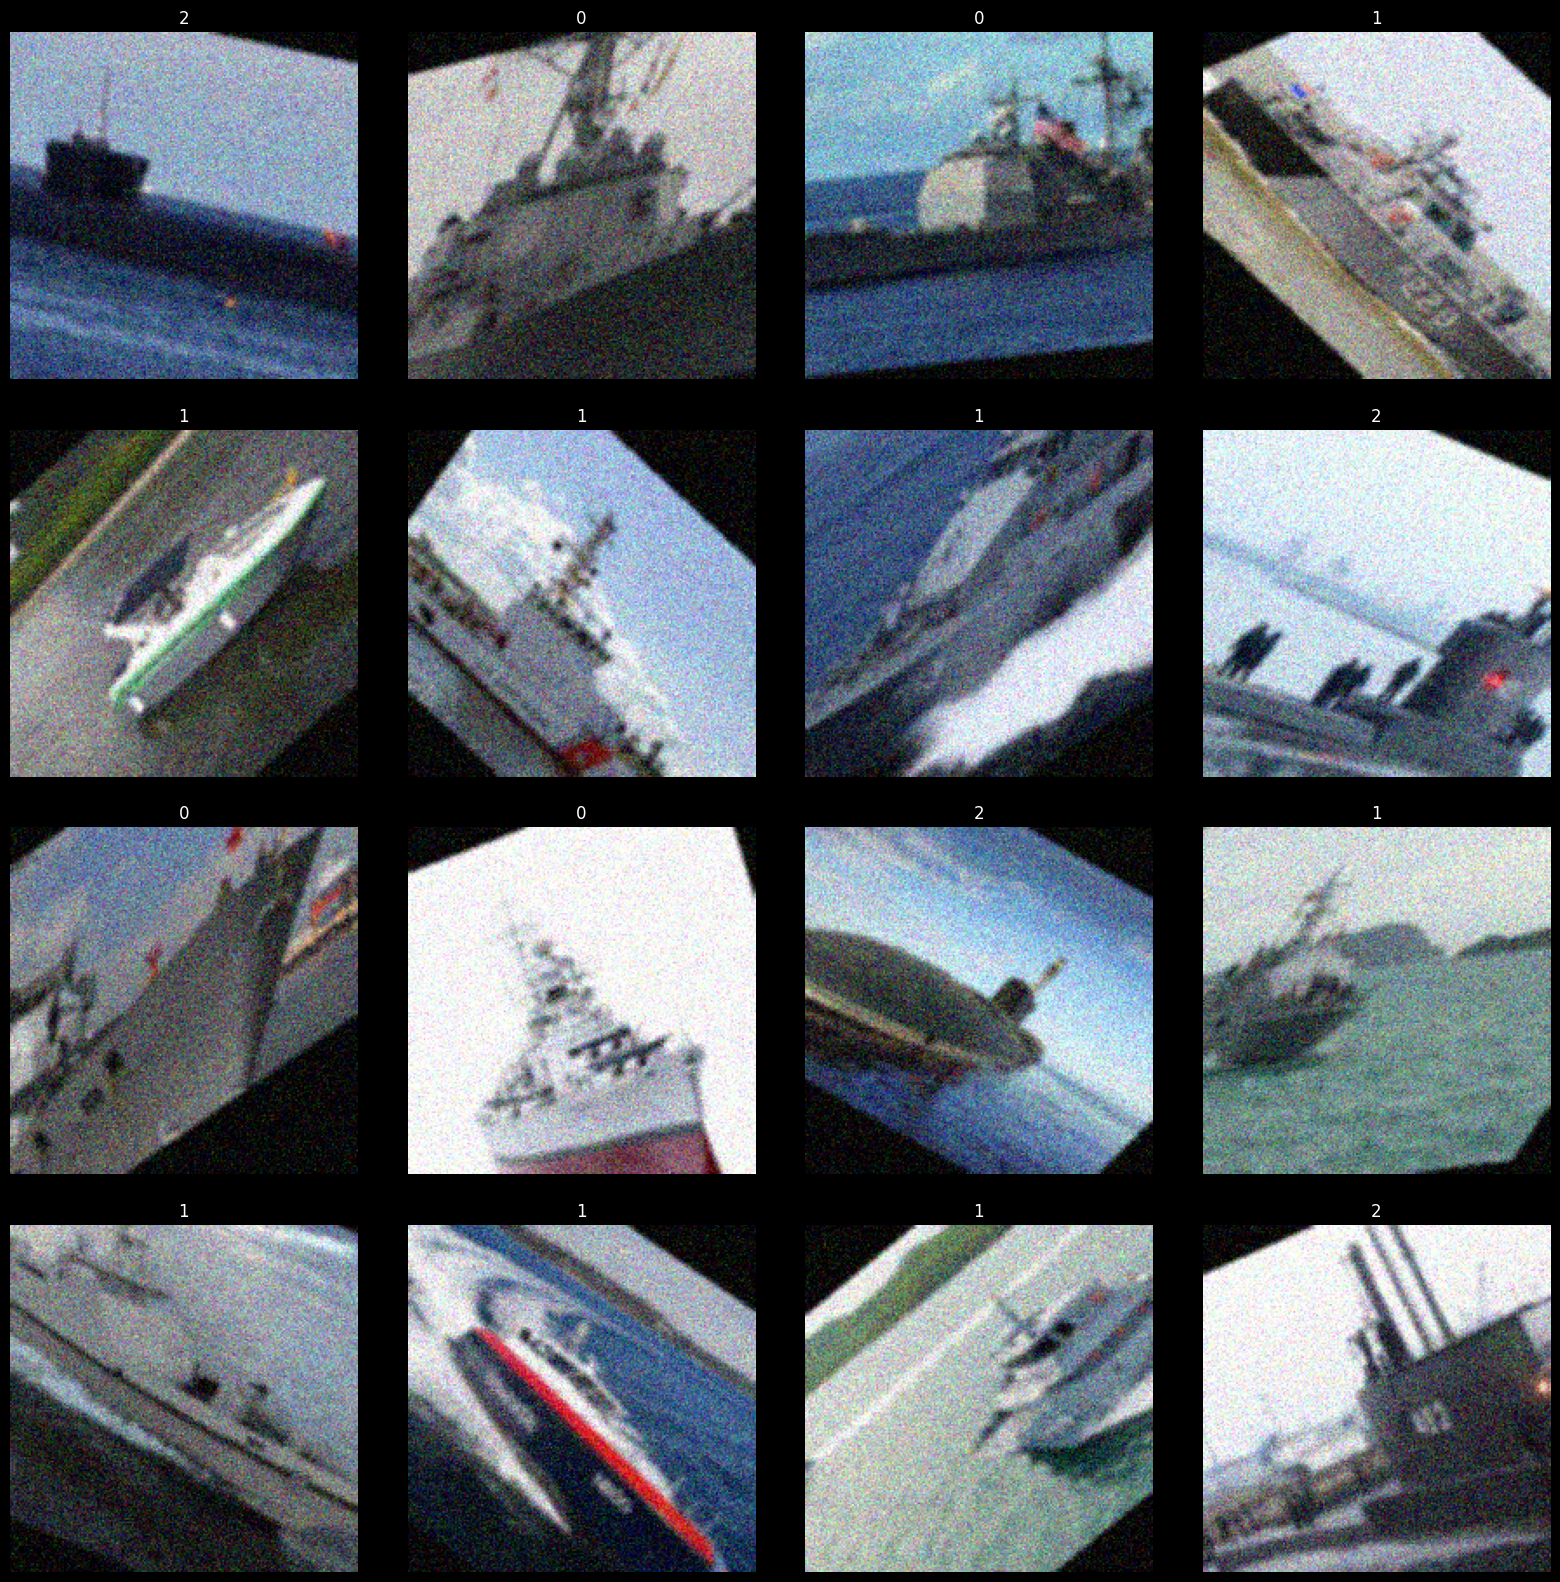

In [16]:
### START CODE HERE ###

dataset = CustomImageDataset(image_dir="./Ship/Ship/Train", output_size=224, apply_blur=True, apply_noise=True)
dataloader = dataset.load_data()

### END CODE HERE ###

Questions
1. Discuss effects and benefits of fill_mode or padding_mode.
2. What would be amount of augmentation should be so that it would not effect the training performance?
3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality?
4. What would be transform parameter to simulate camera lense effect?